# Biomedical Sound Separation Using Generative Models

Diffusion model project for separating mixed biomedical auscultation audio into
heart and lung components.

Recommended runtime: Google Colab GPU.

Dataset idea used here:
- Heart source: PhysioNet heart sound WAV files.
- Lung source: ICBHI respiratory sound WAV files.
- Training pair: create synthetic mixtures by adding one heart clip and one lung clip.
- Target: two clean sources, heart and lung.

This gives a supervised training setup even when real mixed recordings do not
have clean separated ground truth.



## 1. Install dependencies



In [ ]:
!pip -q install librosa soundfile torch torchaudio matplotlib tqdm mir_eval gradio



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

DATA_ROOT = "/content/drive/MyDrive/data/mixed"

TRAIN_HEART_DIR = f"{DATA_ROOT}/train/heart"
TRAIN_LUNG_DIR = f"{DATA_ROOT}/train/lung"
TRAIN_MIXED_DIR = f"{DATA_ROOT}/train/mixed"

VAL_DIR = f"{DATA_ROOT}/val"
TEST_DIR = f"{DATA_ROOT}/test"

RUN_DIR = "/content/diffusion_v1"



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 3. Imports and configuration



In [ ]:
import os
import math
import random
from pathlib import Path

import librosa
import matplotlib.pyplot as plt
import numpy as np
import soundfile as sf
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, random_split
from tqdm.auto import tqdm

os.makedirs(RUN_DIR, exist_ok=True)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

TARGET_SR = 4000
SEGMENT_SECONDS = 8
SEGMENT_SAMPLES = TARGET_SR * SEGMENT_SECO NDS

N_FFT = 512
HOP_LENGTH = 128
WIN_LENGTH = 512

BATCH_SIZE = 8
EPOCHS = 30
LR = 2e-4
NUM_DIFFUSION_STEPS = 200

print("Device:", DEVICE)



Device: cuda


## 4. Dataset utilities



In [ ]:
def list_wavs(folder):
    return sorted(str(p) for p in Path(folder).glob("*.wav"))


def load_audio(path, sr=TARGET_SR):
    y, _ = librosa.load(path, sr=sr, mono=True)
    y = y.astype(np.float32)
    if np.max(np.abs(y)) > 0:
        y = y / (np.max(np.abs(y)) + 1e-8)
    return y


def random_segment(y, length=SEGMENT_SAMPLES):
    if len(y) < length:
        y = np.pad(y, (0, length - len(y)))
    start = random.randint(0, len(y) - length)
    return y[start:start + length]


def rms_normalize(y, target_rms=0.08):
    rms = np.sqrt(np.mean(y ** 2) + 1e-8)
    return y * (target_rms / rms)


def make_mixture(heart, lung):
    heart = rms_normalize(heart, target_rms=random.uniform(0.04, 0.09))
    lung = rms_normalize(lung, target_rms=random.uniform(0.04, 0.09))
    mix = heart + lung
    peak = np.max(np.abs(mix)) + 1e-8
    if peak > 1:
        mix = mix / peak
        heart = heart / peak
        lung = lung / peak
    return mix.astype(np.float32), heart.astype(np.float32), lung.astype(np.float32)


def waveform_to_logmag(y):
    spec = librosa.stft(
        y,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        win_length=WIN_LENGTH,
        window="hann",
    )
    mag = np.abs(spec).astype(np.float32)
    return np.log1p(mag)


def logmag_to_waveform(logmag, phase_source, length=SEGMENT_SAMPLES):
    mag = np.expm1(logmag).clip(min=0)
    spec = mag * np.exp(1j * phase_source)
    y = librosa.istft(
        spec,
        hop_length=HOP_LENGTH,
        win_length=WIN_LENGTH,
        window="hann",
        length=length,
    )
    return y.astype(np.float32)


def mixture_phase(y):
    spec = librosa.stft(
        y,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        win_length=WIN_LENGTH,
        window="hann",
    )
    return np.angle(spec)


class SyntheticHeartLungDataset(Dataset):
    def __init__(self, heart_files, lung_files, examples_per_epoch=2000):
        self.heart_files = heart_files
        self.lung_files = lung_files
        self.examples_per_epoch = examples_per_epoch

    def __len__(self):
        return self.examples_per_epoch

    def __getitem__(self, idx):
        heart = random_segment(load_audio(random.choice(self.heart_files)))
        lung = random_segment(load_audio(random.choice(self.lung_files)))
        mix, heart, lung = make_mixture(heart, lung)

        mix_log = waveform_to_logmag(mix)
        heart_log = waveform_to_logmag(heart)
        lung_log = waveform_to_logmag(lung)

        cond = torch.from_numpy(mix_log).unsqueeze(0)
        target = torch.from_numpy(np.stack([heart_log, lung_log], axis=0))
        return cond, target


heart_files = list_wavs(TRAIN_HEART_DIR)
lung_files = list_wavs(TRAIN_LUNG_DIR)
mixed_files = list_wavs(TRAIN_MIXED_DIR)

print("Heart files:", len(heart_files))
print("Lung files:", len(lung_files))
print("Mixed files:", len(mixed_files))

assert len(heart_files) > 0, "No PhysioNet heart WAV files found."
assert len(lung_files) > 0, "No ICBHI lung WAV files found."

full_ds = SyntheticHeartLungDataset(heart_files, lung_files, examples_per_epoch=1500)
train_len = int(0.9 * len(full_ds))
val_len = len(full_ds) - train_len
train_ds, val_ds = random_split(full_ds, [train_len, val_len])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)



Heart files: 23186
Lung files: 23186
Mixed files: 23186


## 5. Visual sanity check



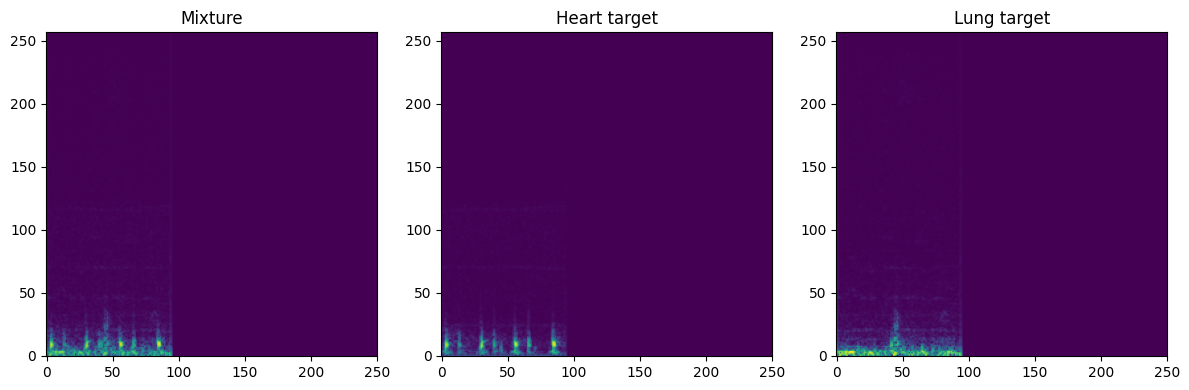

In [ ]:
cond, target = full_ds[0]
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(cond[0], origin="lower", aspect="auto")
plt.title("Mixture")
plt.subplot(1, 3, 2)
plt.imshow(target[0], origin="lower", aspect="auto")
plt.title("Heart target")
plt.subplot(1, 3, 3)
plt.imshow(target[1], origin="lower", aspect="auto")
plt.title("Lung target")
plt.tight_layout()
plt.show()



## 6. Conditional diffusion model

The model receives:
- noisy target spectrograms: 2 channels, heart and lung
- condition spectrogram: 1 channel, mixture
- timestep embedding

It predicts the noise added to the clean target spectrograms.



In [ ]:
class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half = self.dim // 2
        freqs = torch.exp(
            -math.log(10000) * torch.arange(half, device=t.device).float() / max(half - 1, 1)
        )
        args = t.float()[:, None] * freqs[None]
        emb = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)
        if self.dim % 2 == 1:
            emb = F.pad(emb, (0, 1))
        return emb


class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_dim):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.time = nn.Linear(time_dim, out_ch)
        self.norm1 = nn.GroupNorm(8, out_ch)
        self.norm2 = nn.GroupNorm(8, out_ch)

    def forward(self, x, t_emb):
        h = self.conv1(x)
        h = self.norm1(h)
        h = F.silu(h)
        h = h + self.time(t_emb)[:, :, None, None]
        h = self.conv2(h)
        h = self.norm2(h)
        return F.silu(h)


class ConditionalUNet(nn.Module):
    def __init__(self, in_ch=3, out_ch=2, base=32, time_dim=128):
        super().__init__()
        self.time_mlp = nn.Sequential(
            SinusoidalTimeEmbedding(time_dim),
            nn.Linear(time_dim, time_dim),
            nn.SiLU(),
            nn.Linear(time_dim, time_dim),
        )

        self.down1 = ConvBlock(in_ch, base, time_dim)
        self.down2 = ConvBlock(base, base * 2, time_dim)
        self.down3 = ConvBlock(base * 2, base * 4, time_dim)
        self.mid = ConvBlock(base * 4, base * 4, time_dim)

        self.up3 = ConvBlock(base * 8, base * 2, time_dim)
        self.up2 = ConvBlock(base * 4, base, time_dim)
        self.up1 = ConvBlock(base * 2, base, time_dim)
        self.out = nn.Conv2d(base, out_ch, 1)

    def forward(self, noisy_target, cond, t):
        x = torch.cat([noisy_target, cond], dim=1)
        t_emb = self.time_mlp(t)

        d1 = self.down1(x, t_emb)
        d2 = self.down2(F.avg_pool2d(d1, 2), t_emb)
        d3 = self.down3(F.avg_pool2d(d2, 2), t_emb)
        m = self.mid(F.avg_pool2d(d3, 2), t_emb)

        u3 = F.interpolate(m, size=d3.shape[-2:], mode="bilinear", align_corners=False)
        u3 = self.up3(torch.cat([u3, d3], dim=1), t_emb)
        u2 = F.interpolate(u3, size=d2.shape[-2:], mode="bilinear", align_corners=False)
        u2 = self.up2(torch.cat([u2, d2], dim=1), t_emb)
        u1 = F.interpolate(u2, size=d1.shape[-2:], mode="bilinear", align_corners=False)
        u1 = self.up1(torch.cat([u1, d1], dim=1), t_emb)
        return self.out(u1)


def make_beta_schedule(timesteps):
    return torch.linspace(1e-4, 0.02, timesteps)


class Diffusion:
    def __init__(self, timesteps=NUM_DIFFUSION_STEPS, device=DEVICE):
        self.timesteps = timesteps
        self.device = device
        self.betas = make_beta_schedule(timesteps).to(device)
        self.alphas = 1.0 - self.betas
        self.alpha_bars = torch.cumprod(self.alphas, dim=0)

    def q_sample(self, x0, t, noise=None):
        if noise is None:
            noise = torch.randn_like(x0)
        a_bar = self.alpha_bars[t][:, None, None, None]
        return torch.sqrt(a_bar) * x0 + torch.sqrt(1 - a_bar) * noise

    @torch.no_grad()
    def sample(self, model, cond, shape):
        model.eval()
        x = torch.randn(shape, device=self.device)
        for i in tqdm(reversed(range(self.timesteps)), total=self.timesteps, desc="Sampling"):
            t = torch.full((shape[0],), i, device=self.device, dtype=torch.long)
            pred_noise = model(x, cond, t)
            beta = self.betas[i]
            alpha = self.alphas[i]
            alpha_bar = self.alpha_bars[i]
            x = (x - ((1 - alpha) / torch.sqrt(1 - alpha_bar)) * pred_noise) / torch.sqrt(alpha)
            if i > 0:
                x = x + torch.sqrt(beta) * torch.randn_like(x)
        return x


model = ConditionalUNet().to(DEVICE)
diffusion = Diffusion()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

print("Parameters:", sum(p.numel() for p in model.parameters()) / 1e6, "M")



Parameters: 0.93741 M


## 7. Train



In [ ]:
def run_epoch(loader, train=True):
    model.train(train)
    losses = []
    for cond, target in tqdm(loader, leave=False):
        cond = cond.to(DEVICE)
        target = target.to(DEVICE)
        t = torch.randint(0, diffusion.timesteps, (target.size(0),), device=DEVICE).long()
        noise = torch.randn_like(target)
        noisy = diffusion.q_sample(target, t, noise)
        pred = model(noisy, cond, t)
        loss = F.mse_loss(pred, noise)

        if train:
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        losses.append(loss.item())
    return float(np.mean(losses))


best_val = float("inf")
for epoch in range(1, EPOCHS + 1):
    train_loss = run_epoch(train_loader, train=True)
    val_loss = run_epoch(val_loader, train=False)
    print(f"Epoch {epoch:03d} | train={train_loss:.5f} | val={val_loss:.5f}")

    ckpt = {
        "model": model.state_dict(),
        "optimizer": optimizer.state_dict(),
        "epoch": epoch,
        "config": {
            "target_sr": TARGET_SR,
            "segment_seconds": SEGMENT_SECONDS,
            "n_fft": N_FFT,
            "hop_length": HOP_LENGTH,
            "win_length": WIN_LENGTH,
            "diffusion_steps": NUM_DIFFUSION_STEPS,
        },
    }
    torch.save(ckpt, f"{RUN_DIR}/last.pt")
    if val_loss < best_val:
        best_val = val_loss
        torch.save(ckpt, f"{RUN_DIR}/best.pt")



  0%|          | 0/169 [00:00<?, ?it/s]

  0%|          | 0/19 [00:00<?, ?it/s]

Epoch 001 | train=0.15225 | val=0.03928


  0%|          | 0/169 [00:00<?, ?it/s]

  0%|          | 0/19 [00:00<?, ?it/s]

...

  0%|          | 0/19 [00:00<?, ?it/s]

Epoch 029 | train=0.00951 | val=0.00991


  0%|          | 0/169 [00:00<?, ?it/s]

  0%|          | 0/19 [00:00<?, ?it/s]

Epoch 030 | train=0.01063 | val=0.01222


## 8. Separate one mixed recording

This function accepts a WAV file, predicts heart and lung spectrograms, and
reconstructs audio using the mixture phase.



In [ ]:
def load_checkpoint(path=f"{RUN_DIR}/best.pt"):
    ckpt = torch.load(path, map_location=DEVICE)
    model.load_state_dict(ckpt["model"])
    model.eval()
    print("Loaded checkpoint from epoch", ckpt.get("epoch"))


@torch.no_grad()
def separate_wav(input_wav, out_dir=f"{RUN_DIR}/separated"):
    os.makedirs(out_dir, exist_ok=True)
    y = load_audio(input_wav, sr=TARGET_SR)
    y_seg = random_segment(y, SEGMENT_SAMPLES)

    mix_log = waveform_to_logmag(y_seg)
    phase = mixture_phase(y_seg)
    cond = torch.from_numpy(mix_log).unsqueeze(0).unsqueeze(0).to(DEVICE)

    pred = diffusion.sample(model, cond, shape=(1, 2, cond.shape[-2], cond.shape[-1]))
    pred = pred[0].detach().cpu().numpy()

    heart_y = logmag_to_waveform(pred[0], phase, length=SEGMENT_SAMPLES)
    lung_y = logmag_to_waveform(pred[1], phase, length=SEGMENT_SAMPLES)

    stem = Path(input_wav).stem
    mix_path = f"{out_dir}/{stem}_mix_segment.wav"
    heart_path = f"{out_dir}/{stem}_heart_pred.wav"
    lung_path = f"{out_dir}/{stem}_lung_pred.wav"

    sf.write(mix_path, y_seg, TARGET_SR)
    sf.write(heart_path, heart_y, TARGET_SR)
    sf.write(lung_path, lung_y, TARGET_SR)
    return mix_path, heart_path, lung_path


load_checkpoint()
test_mix, test_heart, test_lung = separate_wav(random.choice(lung_files))
print(test_mix)
print(test_heart)
print(test_lung)



Loaded checkpoint from epoch 23


Sampling:   0%|          | 0/200 [00:00<?, ?it/s]

/content/diffusion_v1/separated/pair_003358_mix_segment.wav
/content/diffusion_v1/separated/pair_003358_heart_pred.wav
/content/diffusion_v1/separated/pair_003358_lung_pred.wav


## 9. Objective evaluation on synthetic validation mixtures

Because synthetic mixtures have known clean sources, we can calculate source
quality metrics. SDR improvement over the mixture is the main number to report.



In [ ]:
def si_sdr(reference, estimation, eps=1e-8):
    reference = reference - np.mean(reference)
    estimation = estimation - np.mean(estimation)
    scale = np.sum(estimation * reference) / (np.sum(reference ** 2) + eps)
    target = scale * reference
    noise = estimation - target
    return 10 * np.log10((np.sum(target ** 2) + eps) / (np.sum(noise ** 2) + eps))


@torch.no_grad()
def evaluate_synthetic(n_examples=10):
    scores = []
    for _ in tqdm(range(n_examples), desc="Evaluating"):
        heart = random_segment(load_audio(random.choice(heart_files)))
        lung = random_segment(load_audio(random.choice(lung_files)))
        mix, heart, lung = make_mixture(heart, lung)

        mix_log = waveform_to_logmag(mix)
        phase = mixture_phase(mix)
        cond = torch.from_numpy(mix_log).unsqueeze(0).unsqueeze(0).to(DEVICE)
        pred = diffusion.sample(model, cond, shape=(1, 2, cond.shape[-2], cond.shape[-1]))
        pred = pred[0].detach().cpu().numpy()
        heart_pred = logmag_to_waveform(pred[0], phase, length=SEGMENT_SAMPLES)
        lung_pred = logmag_to_waveform(pred[1], phase, length=SEGMENT_SAMPLES)

        scores.append({
            "heart_si_sdr": si_sdr(heart, heart_pred),
            "lung_si_sdr": si_sdr(lung, lung_pred),
            "heart_mixture_si_sdr": si_sdr(heart, mix),
            "lung_mixture_si_sdr": si_sdr(lung, mix),
        })

    mean_scores = {k: float(np.mean([s[k] for s in scores])) for k in scores[0]}
    mean_scores["heart_improvement"] = mean_scores["heart_si_sdr"] - mean_scores["heart_mixture_si_sdr"]
    mean_scores["lung_improvement"] = mean_scores["lung_si_sdr"] - mean_scores["lung_mixture_si_sdr"]
    return mean_scores


metrics = evaluate_synthetic(n_examples=5)
metrics



Evaluating:   0%|          | 0/5 [00:00<?, ?it/s]

Sampling:   0%|          | 0/200 [00:00<?, ?it/s]

Sampling:   0%|          | 0/200 [00:00<?, ?it/s]

Sampling:   0%|          | 0/200 [00:00<?, ?it/s]

Sampling:   0%|          | 0/200 [00:00<?, ?it/s]

Sampling:   0%|          | 0/200 [00:00<?, ?it/s]

{'heart_si_sdr': -1.2708852291107178,
 'lung_si_sdr': -1.8241173028945923,
 'heart_mixture_si_sdr': -1.1777485609054565,
 'lung_mixture_si_sdr': 1.2660725116729736,
 'heart_improvement': -0.09313666820526123,
 'lung_improvement': -3.090189814567566}

## 10. Optional Gradio demo



In [ ]:
import gradio as gr


def gradio_separate(audio_path):
    mix_path, heart_path, lung_path = separate_wav(audio_path)
    return mix_path, heart_path, lung_path


demo = gr.Interface(
    fn=gradio_separate,
    inputs=gr.Audio(type="filepath", label="Mixed biomedical WAV"),
    outputs=[
        gr.Audio(label="Input segment"),
        gr.Audio(label="Separated heart"),
        gr.Audio(label="Separated lung"),
    ],
    title="Biomedical Sound Separation Using Diffusion",
)

demo.launch(share=True)



Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://812ebcbf6040406c86.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
# ============================================================
# FULL EVALUATION CODE: Accuracy-like score + SI-SDR + SNR + MSE
# For your Biomedical Sound Separation Diffusion Project
# ============================================================

import os
import random
import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm

# -----------------------------
# 1. Load best trained model
# -----------------------------
ckpt_path = f"{RUN_DIR}/best.pt"

if os.path.exists(ckpt_path):
    ckpt = torch.load(ckpt_path, map_location=DEVICE)
    model.load_state_dict(ckpt["model"])
    model.eval()
    print("Loaded best model from:", ckpt_path)
    print("Best epoch:", ckpt.get("epoch", "unknown"))
else:
    model.eval()
    print("No best.pt found. Using current model in memory.")

# -----------------------------
# 2. Metric functions
# -----------------------------
def mse_metric(reference, prediction):
    return float(np.mean((reference - prediction) ** 2))

def mae_metric(reference, prediction):
    return float(np.mean(np.abs(reference - prediction)))

def rmse_metric(reference, prediction):
    return float(np.sqrt(np.mean((reference - prediction) ** 2)))

def snr_metric(reference, prediction, eps=1e-8):
    noise = reference - prediction
    return float(
        10 * np.log10((np.sum(reference ** 2) + eps) / (np.sum(noise ** 2) + eps))
    )

def si_sdr_metric(reference, prediction, eps=1e-8):
    reference = reference.flatten()
    prediction = prediction.flatten()

    reference = reference - np.mean(reference)
    prediction = prediction - np.mean(prediction)

    scale = np.sum(prediction * reference) / (np.sum(reference ** 2) + eps)
    target = scale * reference
    noise = prediction - target

    return float(
        10 * np.log10((np.sum(target ** 2) + eps) / (np.sum(noise ** 2) + eps))
    )

def similarity_accuracy_percent(reference, prediction, eps=1e-8):
    """
    Accuracy-like score for separation.
    100% means predicted signal/spectrogram is very similar to target.
    """
    reference = reference.flatten()
    prediction = prediction.flatten()

    cosine = np.dot(reference, prediction) / (
        np.linalg.norm(reference) * np.linalg.norm(prediction) + eps
    )

    cosine = np.clip(cosine, -1, 1)

    # Convert cosine range [-1, 1] to percentage [0, 100]
    return float((cosine + 1) * 50)

# -----------------------------
# 3. Evaluate on synthetic known mixtures
# -----------------------------
@torch.no_grad()
def evaluate_diffusion_separation(n_examples=10):
    rows = []

    for i in tqdm(range(n_examples), desc="Evaluating model"):
        # Create known test sample
        heart = random_segment(load_audio(random.choice(heart_files)))
        lung = random_segment(load_audio(random.choice(lung_files)))

        mix, heart, lung = make_mixture(heart, lung)

        # Convert mixture to spectrogram condition
        mix_log = waveform_to_logmag(mix)
        phase = mixture_phase(mix)

        cond = torch.from_numpy(mix_log).unsqueeze(0).unsqueeze(0).to(DEVICE)

        # Predict heart and lung spectrograms using diffusion
        pred = diffusion.sample(
            model,
            cond,
            shape=(1, 2, cond.shape[-2], cond.shape[-1])
        )

        pred = pred[0].detach().cpu().numpy()

        pred_heart_spec = pred[0]
        pred_lung_spec = pred[1]

        # Convert predicted spectrograms back to audio
        pred_heart_audio = logmag_to_waveform(
            pred_heart_spec,
            phase,
            length=SEGMENT_SAMPLES
        )

        pred_lung_audio = logmag_to_waveform(
            pred_lung_spec,
            phase,
            length=SEGMENT_SAMPLES
        )

        # True spectrograms
        true_heart_spec = waveform_to_logmag(heart)
        true_lung_spec = waveform_to_logmag(lung)

        row = {
            "sample": i,

            # Accuracy-like spectrogram similarity
            "heart_accuracy_percent": similarity_accuracy_percent(true_heart_spec, pred_heart_spec),
            "lung_accuracy_percent": similarity_accuracy_percent(true_lung_spec, pred_lung_spec),

            # Spectrogram error
            "heart_spectrogram_mse": mse_metric(true_heart_spec, pred_heart_spec),
            "lung_spectrogram_mse": mse_metric(true_lung_spec, pred_lung_spec),
            "heart_spectrogram_mae": mae_metric(true_heart_spec, pred_heart_spec),
            "lung_spectrogram_mae": mae_metric(true_lung_spec, pred_lung_spec),

            # Waveform error
            "heart_waveform_mse": mse_metric(heart, pred_heart_audio),
            "lung_waveform_mse": mse_metric(lung, pred_lung_audio),
            "heart_waveform_rmse": rmse_metric(heart, pred_heart_audio),
            "lung_waveform_rmse": rmse_metric(lung, pred_lung_audio),

            # Separation quality
            "heart_si_sdr_db": si_sdr_metric(heart, pred_heart_audio),
            "lung_si_sdr_db": si_sdr_metric(lung, pred_lung_audio),
            "heart_snr_db": snr_metric(heart, pred_heart_audio),
            "lung_snr_db": snr_metric(lung, pred_lung_audio),

            # Baseline: how good is original mixture without separation?
            "heart_mixture_si_sdr_db": si_sdr_metric(heart, mix),
            "lung_mixture_si_sdr_db": si_sdr_metric(lung, mix),
        }

        row["overall_accuracy_percent"] = np.mean([
            row["heart_accuracy_percent"],
            row["lung_accuracy_percent"]
        ])

        row["overall_si_sdr_db"] = np.mean([
            row["heart_si_sdr_db"],
            row["lung_si_sdr_db"]
        ])

        row["overall_snr_db"] = np.mean([
            row["heart_snr_db"],
            row["lung_snr_db"]
        ])

        row["heart_si_sdr_improvement_db"] = (
            row["heart_si_sdr_db"] - row["heart_mixture_si_sdr_db"]
        )

        row["lung_si_sdr_improvement_db"] = (
            row["lung_si_sdr_db"] - row["lung_mixture_si_sdr_db"]
        )

        row["overall_si_sdr_improvement_db"] = np.mean([
            row["heart_si_sdr_improvement_db"],
            row["lung_si_sdr_improvement_db"]
        ])

        rows.append(row)

    detailed_df = pd.DataFrame(rows)
    summary_df = detailed_df.mean(numeric_only=True).to_frame(name="mean_value")

    return detailed_df, summary_df

# -----------------------------
# 4. Run evaluation
# -----------------------------
# Start with 5. Later use 10, 20, or 50.
detailed_metrics, summary_metrics = evaluate_diffusion_separation(n_examples=5)

print("\nDetailed Metrics:")
display(detailed_metrics)

print("\nAverage / Final Metrics:")
display(summary_metrics)

# -----------------------------
# 5. Save metrics
# -----------------------------
metrics_dir = f"{RUN_DIR}/metrics"
os.makedirs(metrics_dir, exist_ok=True)

detailed_path = f"{metrics_dir}/detailed_metrics.csv"
summary_path = f"{metrics_dir}/summary_metrics.csv"

detailed_metrics.to_csv(detailed_path, index=False)
summary_metrics.to_csv(summary_path)

print("Saved detailed metrics to:", detailed_path)
print("Saved summary metrics to:", summary_path)

# -----------------------------
# 6. Print report-friendly values
# -----------------------------
print("\n========== REPORT VALUES ==========")
print(f"Overall Accuracy (%): {summary_metrics.loc['overall_accuracy_percent', 'mean_value']:.2f}")
print(f"Heart Accuracy (%): {summary_metrics.loc['heart_accuracy_percent', 'mean_value']:.2f}")
print(f"Lung Accuracy (%): {summary_metrics.loc['lung_accuracy_percent', 'mean_value']:.2f}")
print(f"Overall SI-SDR (dB): {summary_metrics.loc['overall_si_sdr_db', 'mean_value']:.2f}")
print(f"Heart SI-SDR (dB): {summary_metrics.loc['heart_si_sdr_db', 'mean_value']:.2f}")
print(f"Lung SI-SDR (dB): {summary_metrics.loc['lung_si_sdr_db', 'mean_value']:.2f}")
print(f"Overall SI-SDR Improvement (dB): {summary_metrics.loc['overall_si_sdr_improvement_db', 'mean_value']:.2f}")
print(f"Overall SNR (dB): {summary_metrics.loc['overall_snr_db', 'mean_value']:.2f}")
print(f"Heart Spectrogram MSE: {summary_metrics.loc['heart_spectrogram_mse', 'mean_value']:.4f}")
print(f"Lung Spectrogram MSE: {summary_metrics.loc['lung_spectrogram_mse', 'mean_value']:.4f}")

Loaded best model from: /content/diffusion_v1/best.pt
Best epoch: 23


Evaluating model:   0%|          | 0/5 [00:00<?, ?it/s]

Sampling:   0%|          | 0/200 [00:00<?, ?it/s]

Sampling:   0%|          | 0/200 [00:00<?, ?it/s]

Sampling:   0%|          | 0/200 [00:00<?, ?it/s]

...


Detailed Metrics:


,sample,heart_accuracy_percent,lung_accuracy_percent,heart_spectrogram_mse,lung_spectrogram_mse,heart_spectrogram_mae,lung_spectrogram_mae,heart_waveform_mse,lung_waveform_mse,heart_waveform_rmse,lung_waveform_rmse,heart_si_sdr_db,lung_si_sdr_db,heart_snr_db,lung_snr_db,heart_mixture_si_sdr_db,lung_mixture_si_sdr_db,overall_accuracy_percent,overall_si_sdr_db,overall_snr_db,heart_si_sdr_improvement_db,lung_si_sdr_improvement_db,overall_si_sdr_improvement_db
0,0,95.458969,94.630737,0.008611,0.011936,0.052231,0.024971,0.001022,0.003235,0.031975,0.056874,5.716646,5.612940,6.503034,3.121646,-1.332129,1.400532,95.044853,5.664793,4.812340,7.048775,4.212408,5.630591
1,1,87.837059,87.048187,0.025551,0.016111,0.087878,0.043589,0.001497,0.000927,0.038693,0.030443,2.240230,-5.826301,3.748001,0.828187,4.869604,-5.306630,87.442623,-1.793035,2.288094,-2.629373,-0.519670,-1.574522
2,2,92.395149,89.326347,0.017672,0.021780,0.067590,0.035852,0.002658,0.002195,0.051553,0.046852,0.563955,-5.299928,3.282787,1.115947,3.195185,-2.611936,90.860748,-2.367987,2.199367,-2.631231,-2.687992,-2.659611
3,3,88.993919,85.029938,0.025388,0.042517,0.089133,0.062132,0.001778,0.003883,0.042167,0.062317,0.374028,-0.575954,2.733681,1.434596,-1.767585,2.295294,87.011929,-0.100963,2.084139,2.141612,-2.871248,-0.364818
4,4,84.605240,77.979385,0.015682,0.016113,0.074646,0.028269,0.001582,0.001316,0.039777,0.036271,-3.636655,-12.880077,1.438642,0.116613,1.938943,-1.747139,81.292313,-8.258366,0.777628,-5.575597,-11.132938,-8.354268



Average / Final Metrics:


,mean_value
sample,2.000000
heart_accuracy_percent,89.858067
lung_accuracy_percent,86.802919
heart_spectrogram_mse,0.018581
lung_spectrogram_mse,0.021692
heart_spectrogram_mae,0.074296
lung_spectrogram_mae,0.038963
heart_waveform_mse,0.001707
lung_waveform_mse,0.002311
heart_waveform_rmse,0.040833


Saved detailed metrics to: /content/diffusion_v1/metrics/detailed_metrics.csv
Saved summary metrics to: /content/diffusion_v1/metrics/summary_metrics.csv

========== REPORT VALUES ==========
Overall Accuracy (%): 88.33
Heart Accuracy (%): 89.86
Lung Accuracy (%): 86.80
Overall SI-SDR (dB): -1.37
Heart SI-SDR (dB): 1.05
Lung SI-SDR (dB): -3.79
Overall SI-SDR Improvement (dB): -1.46
Overall SNR (dB): 2.43
Heart Spectrogram MSE: 0.0186
Lung Spectrogram MSE: 0.0217


In [ ]:
!zip -r diffusion_v1.zip /content/diffusion_v1

  adding: content/diffusion_v1/ (stored 0%)
  adding: content/diffusion_v1/separated/ (stored 0%)
  adding: content/diffusion_v1/separated/pair_003358_lung_pred.wav (deflated 47%)
  adding: content/diffusion_v1/separated/pair_000001_lung_pred.wav (deflated 37%)
  adding: content/diffusion_v1/separated/pair_003358_heart_pred.wav (deflated 64%)
  adding: content/diffusion_v1/separated/pair_000001_mix_segment.wav (deflated 64%)
  adding: content/diffusion_v1/separated/pair_003358_mix_segment.wav (deflated 63%)
  adding: content/diffusion_v1/separated/pair_000001_heart_pred.wav (deflated 65%)
  adding: content/diffusion_v1/metrics/ (stored 0%)
  adding: content/diffusion_v1/metrics/detailed_metrics.csv (deflated 51%)
  adding: content/diffusion_v1/metrics/summary_metrics.csv (deflated 56%)
  adding: content/diffusion_v1/best.pt (deflated 8%)
  adding: content/diffusion_v1/last.pt (deflated 8%)


In [ ]:
from google.colab import files
files.download("diffusion_v1.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import shutil
import os

source = "/content/diffusion_v1"
destination = "/content/drive/MyDrive/diffusion_v1"

# Remove old folder if it already exists
if os.path.exists(destination):
    shutil.rmtree(destination)

# Copy entire folder
shutil.copytree(source, destination)

print("Entire diffusion_v1 folder copied to Google Drive successfully!")

Entire diffusion_v1 folder copied to Google Drive successfully!
